In [ ]:
!pip install Optuna

In [ ]:
!pip install yaspin

In [ ]:
!pip install tensorflow

In [ ]:
import glob, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler,MinMaxScaler
import IPython
from IPython.display import Image,display
import tensorflow as tf
import seaborn as sns

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model

import optuna
from yaspin import yaspin
import time
from time import sleep

import joblib
from sklearn.utils import parallel_backend

In [ ]:
#!gdown 11ZVumrV39vllTr403Mwbk0mhBsOGdtj4

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
filepath='/content/drive/MyDrive/EngineData/*.csv'
input_files=glob.glob(filepath)

input_files

['/content/drive/MyDrive/EngineData/20180713-mimos2home.csv',
 '/content/drive/MyDrive/EngineData/20180717-mimos2home.csv',
 '/content/drive/MyDrive/EngineData/20180718-mimos2home.csv',
 '/content/drive/MyDrive/EngineData/20180713-home2mimos.csv',
 '/content/drive/MyDrive/EngineData/20180716-home2mimos.csv',
 '/content/drive/MyDrive/EngineData/20180718-home2mimos.csv',
 '/content/drive/MyDrive/EngineData/20180716-mimos2home.csv',
 '/content/drive/MyDrive/EngineData/20180717-home2mimos.csv',
 '/content/drive/MyDrive/EngineData/20180720-home2mimos.csv',
 '/content/drive/MyDrive/EngineData/20180727-home2mimos.csv',
 '/content/drive/MyDrive/EngineData/20180719-home2mimos.csv',
 '/content/drive/MyDrive/EngineData/20180731-mimos2home.csv',
 '/content/drive/MyDrive/EngineData/20180730-mimos2home.csv',
 '/content/drive/MyDrive/EngineData/20180803-mimos2home.csv',
 '/content/drive/MyDrive/EngineData/20180801-mimos2home.csv',
 '/content/drive/MyDrive/EngineData/20180731-home2mimos.csv',
 '/conte

In [ ]:
dff=[]

## input file names

## read all data

In [ ]:
all_data = None
for i in range(len(input_files)):
    csv_columns = []
    csv_columns.append('time')
    header_number = 0
    channel = ""
    with open(input_files[i]) as f:
        lines = f.readlines()
        for line in lines:
            header_number += 1
            if line.startswith('Channel : '):
                channel = line.replace('Channel : ','').replace('\n','')
            if line.startswith('Type : '):
                csv_columns.append(channel + "[" + line.replace('Type : ','').replace('\n','') + "]")
            if line.startswith('Log : '):
                break
    print("{} header={}  file={}".format(i+1, header_number, input_files[i]))
    df = pd.read_csv(input_files[i], index_col=False, skiprows=header_number, names=csv_columns)

    basename = os.path.basename(input_files[i])
    df['date'] = basename.replace('.csv','').split('-')[0]
    route = basename.replace('.csv','').split('-')[1]
    df['route'] = route
    df['time'] = df['date'] + " " + df['time']
    df['time'] = pd.to_datetime( df['time'], format="%Y%m%d %H:%M:%S.%f")
    df['#time_diff'] = df['time'].diff(1).dt.total_seconds()
    df['#time_seq'] = df['#time_diff'].cumsum()
    df['#road_seq'] = df['#time_seq']
    if route == "mimos2home":
        df['#road_seq'] = df['#road_seq'].max() - df['#road_seq']

    if all_data is None:
        all_data = df
    else:
        all_data = pd.concat([all_data, df])
    dff.append(df)
all_data

1 header=63  file=/content/drive/MyDrive/EngineData/20180713-mimos2home.csv
2 header=84  file=/content/drive/MyDrive/EngineData/20180717-mimos2home.csv
3 header=84  file=/content/drive/MyDrive/EngineData/20180718-mimos2home.csv
4 header=63  file=/content/drive/MyDrive/EngineData/20180713-home2mimos.csv
5 header=84  file=/content/drive/MyDrive/EngineData/20180716-home2mimos.csv
6 header=84  file=/content/drive/MyDrive/EngineData/20180718-home2mimos.csv
7 header=84  file=/content/drive/MyDrive/EngineData/20180716-mimos2home.csv
8 header=84  file=/content/drive/MyDrive/EngineData/20180717-home2mimos.csv
9 header=84  file=/content/drive/MyDrive/EngineData/20180720-home2mimos.csv
10 header=84  file=/content/drive/MyDrive/EngineData/20180727-home2mimos.csv
11 header=84  file=/content/drive/MyDrive/EngineData/20180719-home2mimos.csv
12 header=84  file=/content/drive/MyDrive/EngineData/20180731-mimos2home.csv
13 header=84  file=/content/drive/MyDrive/EngineData/20180730-mimos2home.csv
14 heade

,time,BaseFuel[Percentage],BaseIgnition[AngleIgnSprt2K],TargetAFR[AFR],FuelCoolantTempCorrection[Percentage1For1],FuelAirTempCorrection[Percentage],ThrottlePosition[Percentage],AirTemp[Temperature],CoolantTemp[Temperature],LambdaSensor1[AFR],...,ShiftLight1[Raw],IgnitionCoolantTempCorrection[AngleOffset10deg],IgnitionAirTempCorrection[Angle],TransientThrottleAccelCoolantCorr[Percentage],TransientThrottleEnrichSensitivity[Time_us],TransientThrottleEnrichDecayRate[msPerEngCyl],TransientThrottlePercentageAsync[Percentage],TransientThrottlePercentageEnrich[Percentage],Pwm_State_2[Raw],Pwm_State_1[Raw]
0,2018-07-13 08:27:21.000,351.0,325.0,1000.0,0.0,0.0,2.0,3074.0,3303.0,940.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-07-13 08:27:21.031,349.0,326.0,NaN,NaN,NaN,NaN,NaN,NaN,942.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-07-13 08:27:21.047,352.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-07-13 08:27:21.062,NaN,327.0,NaN,NaN,NaN,NaN,NaN,NaN,948.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-07-13 08:27:21.078,356.0,325.0,NaN,NaN,NaN,NaN,3074.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24821,2018-08-23 06:42:27.110,333.0,NaN,NaN,NaN,NaN,5.0,NaN,3542.0,1033.0,...,NaN,NaN,NaN,NaN,2572.0,NaN,775.0,NaN,NaN,NaN
24822,2018-08-23 06:42:27.203,334.0,NaN,NaN,NaN,NaN,4.0,NaN,3540.0,1034.0,...,NaN,NaN,NaN,NaN,2559.0,NaN,773.0,NaN,NaN,NaN
24823,2018-08-23 06:42:27.297,NaN,NaN,NaN,NaN,NaN,5.0,NaN,3542.0,1030.0,...,NaN,NaN,NaN,NaN,2564.0,NaN,774.0,NaN,NaN,NaN
24824,2018-08-23 06:42:27.375,334.0,300.0,1000.0,0.0,0.0,4.0,3353.0,3542.0,1023.0,...,0.0,110.0,12.0,0.0,2554.0,1000.0,772.0,0.0,0.0,0.0


In [ ]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1414545 entries, 0 to 24825
Data columns (total 36 columns):
 #   Column                                           Non-Null Count    Dtype         
---  ------                                           --------------    -----         
 0   time                                             1414545 non-null  datetime64[ns]
 1   BaseFuel[Percentage]                             1208992 non-null  float64       
 2   BaseIgnition[AngleIgnSprt2K]                     872057 non-null   float64       
 3   TargetAFR[AFR]                                   259791 non-null   float64       
 4   FuelCoolantTempCorrection[Percentage1For1]       150 non-null      float64       
 5   FuelAirTempCorrection[Percentage]                150 non-null      float64       
 6   ThrottlePosition[Percentage]                     735286 non-null   float64       
 7   AirTemp[Temperature]                             485318 non-null   float64       
 8   CoolantTemp[Tempera

In [ ]:
print(all_data)

                         time  BaseFuel[Percentage]  \
0     2018-07-13 08:27:21.000                 351.0   
1     2018-07-13 08:27:21.031                 349.0   
2     2018-07-13 08:27:21.047                 352.0   
3     2018-07-13 08:27:21.062                   NaN   
4     2018-07-13 08:27:21.078                 356.0   
...                       ...                   ...   
24821 2018-08-23 06:42:27.110                 333.0   
24822 2018-08-23 06:42:27.203                 334.0   
24823 2018-08-23 06:42:27.297                   NaN   
24824 2018-08-23 06:42:27.375                 334.0   
24825 2018-08-23 06:42:27.375                 334.0   

       BaseIgnition[AngleIgnSprt2K]  TargetAFR[AFR]  \
0                             325.0          1000.0   
1                             326.0             NaN   
2                               NaN             NaN   
3                             327.0             NaN   
4                             325.0             NaN   
...      

## Scatter plot

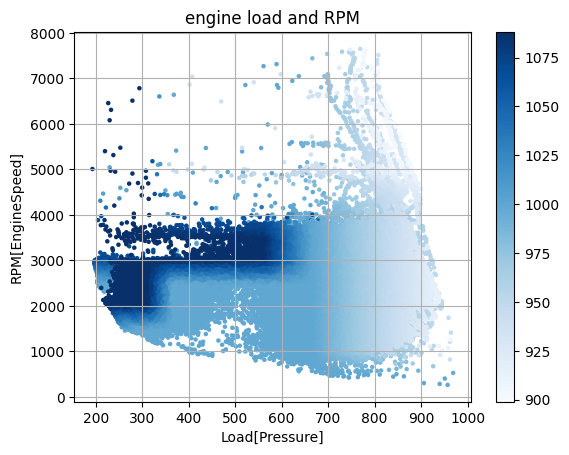

In [ ]:
plt.scatter(all_data['Load[Pressure]'], all_data['RPM[EngineSpeed]'], c=all_data['TargetAFR[AFR]'], cmap='Blues', s=5)
plt.colorbar()
plt.title("engine load and RPM")
plt.xlabel("Load[Pressure]")
plt.ylabel("RPM[EngineSpeed]")
plt.grid(True)

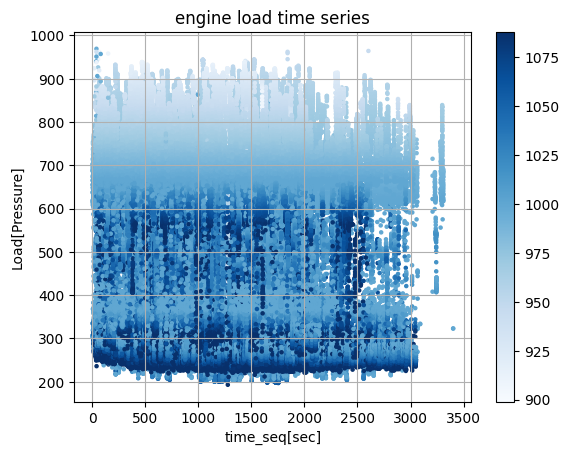

In [ ]:
plt.scatter(all_data['#time_seq'], all_data['Load[Pressure]'], c=all_data['TargetAFR[AFR]'], cmap='Blues', s=5)
plt.colorbar()
plt.title("engine load time series")
plt.xlabel("time_seq[sec]")
plt.ylabel("Load[Pressure]")
plt.grid(True)

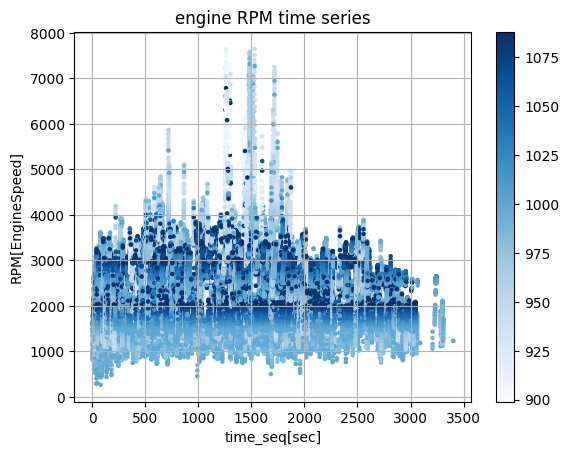

In [ ]:
plt.scatter(all_data['#time_seq'], all_data['RPM[EngineSpeed]'], c=all_data['TargetAFR[AFR]'], cmap='Blues', s=5)
plt.colorbar()
plt.title("engine RPM time series")
plt.xlabel("time_seq[sec]")
plt.ylabel("RPM[EngineSpeed]")
plt.grid(True)

#Visualizing The Data And Cleaning


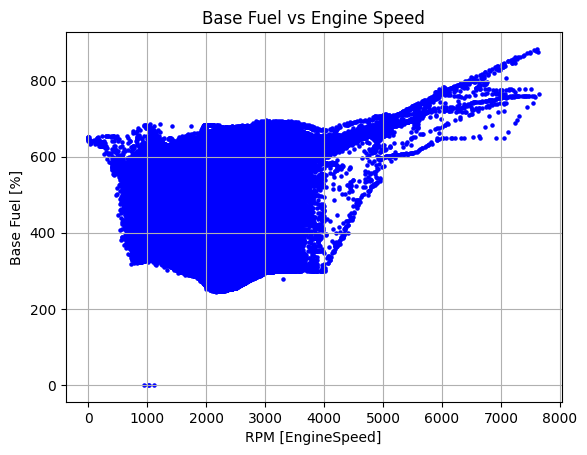

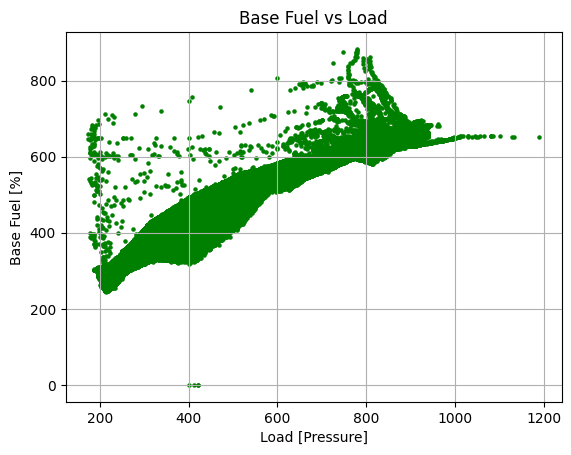

In [ ]:
# Scatter plot:BaseFuel vs RPM
plt.scatter(all_data['RPM[EngineSpeed]'], all_data['BaseFuel[Percentage]'], c='blue', s=5)
plt.title("Base Fuel vs Engine Speed")
plt.xlabel("RPM [EngineSpeed]")
plt.ylabel("Base Fuel [%]")
plt.grid(True)
plt.show()

# Scatter plot:BaseFuel vs Load
plt.scatter(all_data['Load[Pressure]'], all_data['BaseFuel[Percentage]'], c='green', s=5)
plt.title("Base Fuel vs Load")
plt.xlabel("Load [Pressure]")
plt.ylabel("Base Fuel [%]")
plt.grid(True)
plt.show()

In [ ]:
all_data

,time,BaseFuel[Percentage],BaseIgnition[AngleIgnSprt2K],TargetAFR[AFR],FuelCoolantTempCorrection[Percentage1For1],FuelAirTempCorrection[Percentage],ThrottlePosition[Percentage],AirTemp[Temperature],CoolantTemp[Temperature],LambdaSensor1[AFR],...,ShiftLight1[Raw],IgnitionCoolantTempCorrection[AngleOffset10deg],IgnitionAirTempCorrection[Angle],TransientThrottleAccelCoolantCorr[Percentage],TransientThrottleEnrichSensitivity[Time_us],TransientThrottleEnrichDecayRate[msPerEngCyl],TransientThrottlePercentageAsync[Percentage],TransientThrottlePercentageEnrich[Percentage],Pwm_State_2[Raw],Pwm_State_1[Raw]
0,2018-07-13 08:27:21.000,351.0,325.0,1000.0,0.0,0.0,2.0,3074.0,3303.0,940.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-07-13 08:27:21.031,349.0,326.0,NaN,NaN,NaN,NaN,NaN,NaN,942.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-07-13 08:27:21.047,352.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-07-13 08:27:21.062,NaN,327.0,NaN,NaN,NaN,NaN,NaN,NaN,948.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-07-13 08:27:21.078,356.0,325.0,NaN,NaN,NaN,NaN,3074.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24821,2018-08-23 06:42:27.110,333.0,NaN,NaN,NaN,NaN,5.0,NaN,3542.0,1033.0,...,NaN,NaN,NaN,NaN,2572.0,NaN,775.0,NaN,NaN,NaN
24822,2018-08-23 06:42:27.203,334.0,NaN,NaN,NaN,NaN,4.0,NaN,3540.0,1034.0,...,NaN,NaN,NaN,NaN,2559.0,NaN,773.0,NaN,NaN,NaN
24823,2018-08-23 06:42:27.297,NaN,NaN,NaN,NaN,NaN,5.0,NaN,3542.0,1030.0,...,NaN,NaN,NaN,NaN,2564.0,NaN,774.0,NaN,NaN,NaN
24824,2018-08-23 06:42:27.375,334.0,300.0,1000.0,0.0,0.0,4.0,3353.0,3542.0,1023.0,...,0.0,110.0,12.0,0.0,2554.0,1000.0,772.0,0.0,0.0,0.0


In [ ]:
# threshold for skipping intervals is 40% Nans lesser or more changes the amount of dataset filtered significantly.
nan_threshold = 0.4

# grouping by 'time'
all_data['time_interval'] = all_data['time'].dt.floor('T')  # floor to nearest minute for grouping.

# percentage of NaN values for each time interval.
nan_percentage_per_interval = all_data.groupby('time_interval').apply(lambda x: x.isnull().mean())

# intervals to keep.
valid_intervals = nan_percentage_per_interval[nan_percentage_per_interval.mean(axis=1) <= nan_threshold].index
filtered_data = all_data[all_data['time_interval'].isin(valid_intervals)]
filtered_data.drop(columns=['time_interval'], inplace=True)

print(f"Number of skipped intervals: {len(nan_percentage_per_interval) - len(valid_intervals)}")
print(f"Remaining data shape: {filtered_data.shape}")

print(filtered_data.head())


<ipython-input-21-6466d9d9d109>:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  all_data['time_interval'] = all_data['time'].dt.floor('T')  # floor to nearest minute for grouping.


Number of skipped intervals: 1553
Remaining data shape: (13418, 36)
                         time  BaseFuel[Percentage]  \
20624 2018-07-17 08:22:00.047                 558.0   
20625 2018-07-17 08:22:00.141                 554.0   
20626 2018-07-17 08:22:00.219                 552.0   
20627 2018-07-17 08:22:00.297                 547.0   
20628 2018-07-17 08:22:00.391                 540.0   

       BaseIgnition[AngleIgnSprt2K]  TargetAFR[AFR]  \
20624                         242.0           993.0   
20625                         244.0           994.0   
20626                         245.0           994.0   
20627                         247.0           995.0   
20628                         251.0           996.0   

       FuelCoolantTempCorrection[Percentage1For1]  \
20624                                         NaN   
20625                                         NaN   
20626                                         NaN   
20627                                         NaN   
20628

<ipython-input-21-6466d9d9d109>:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nan_percentage_per_interval = all_data.groupby('time_interval').apply(lambda x: x.isnull().mean())
<ipython-input-21-6466d9d9d109>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.drop(columns=['time_interval'], inplace=True)


In [ ]:
filtered_data

,time,BaseFuel[Percentage],BaseIgnition[AngleIgnSprt2K],TargetAFR[AFR],FuelCoolantTempCorrection[Percentage1For1],FuelAirTempCorrection[Percentage],ThrottlePosition[Percentage],AirTemp[Temperature],CoolantTemp[Temperature],LambdaSensor1[AFR],...,ShiftLight1[Raw],IgnitionCoolantTempCorrection[AngleOffset10deg],IgnitionAirTempCorrection[Angle],TransientThrottleAccelCoolantCorr[Percentage],TransientThrottleEnrichSensitivity[Time_us],TransientThrottleEnrichDecayRate[msPerEngCyl],TransientThrottlePercentageAsync[Percentage],TransientThrottlePercentageEnrich[Percentage],Pwm_State_2[Raw],Pwm_State_1[Raw]
20624,2018-07-17 08:22:00.047,558.0,242.0,993.0,NaN,NaN,67.0,NaN,3499.0,1126.0,...,NaN,NaN,NaN,32.0,1825.0,936.0,717.0,NaN,NaN,NaN
20625,2018-07-17 08:22:00.141,554.0,244.0,994.0,NaN,NaN,66.0,NaN,3499.0,1125.0,...,NaN,NaN,NaN,NaN,1839.0,NaN,717.0,NaN,NaN,NaN
20626,2018-07-17 08:22:00.219,552.0,245.0,994.0,NaN,NaN,65.0,NaN,3497.0,1093.0,...,NaN,NaN,NaN,32.0,1837.0,936.0,715.0,NaN,NaN,NaN
20627,2018-07-17 08:22:00.297,547.0,247.0,995.0,NaN,NaN,65.0,NaN,NaN,1095.0,...,NaN,NaN,NaN,34.0,1835.0,932.0,715.0,NaN,NaN,NaN
20628,2018-07-17 08:22:00.391,540.0,251.0,996.0,NaN,NaN,64.0,NaN,NaN,1078.0,...,NaN,NaN,11.0,32.0,1834.0,936.0,713.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23182,2018-08-23 06:39:59.516,306.0,332.0,NaN,NaN,NaN,5.0,NaN,NaN,887.0,...,NaN,NaN,NaN,NaN,1892.0,NaN,632.0,NaN,NaN,NaN
23183,2018-08-23 06:39:59.610,305.0,328.0,NaN,NaN,NaN,7.0,3329.0,NaN,811.0,...,NaN,NaN,NaN,NaN,1913.0,NaN,647.0,NaN,NaN,NaN
23184,2018-08-23 06:39:59.688,312.0,324.0,1088.0,NaN,NaN,6.0,3328.0,NaN,810.0,...,NaN,NaN,NaN,NaN,1944.0,NaN,661.0,NaN,NaN,NaN
23185,2018-08-23 06:39:59.782,319.0,320.0,1068.0,NaN,NaN,7.0,3329.0,NaN,780.0,...,NaN,NaN,NaN,NaN,2025.0,NaN,679.0,NaN,NaN,NaN


In [ ]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1414545 entries, 0 to 24825
Data columns (total 37 columns):
 #   Column                                           Non-Null Count    Dtype         
---  ------                                           --------------    -----         
 0   time                                             1414545 non-null  datetime64[ns]
 1   BaseFuel[Percentage]                             1208992 non-null  float64       
 2   BaseIgnition[AngleIgnSprt2K]                     872057 non-null   float64       
 3   TargetAFR[AFR]                                   259791 non-null   float64       
 4   FuelCoolantTempCorrection[Percentage1For1]       150 non-null      float64       
 5   FuelAirTempCorrection[Percentage]                150 non-null      float64       
 6   ThrottlePosition[Percentage]                     735286 non-null   float64       
 7   AirTemp[Temperature]                             485318 non-null   float64       
 8   CoolantTemp[Tempera

Here We have scaled values for air-fuel ratios. Many ECUs (Engine Control Units) store sensor values—especially ratios like the air‐fuel ratio (AFR) or lambda value—in a “scaled” format to preserve precision without relying on floating point numbers.

In [ ]:
filtered_data1=filtered_data
dff[0][['AFRDifference[AFR]','TargetAFR[AFR]','LambdaSensor1[AFR]','RPM[EngineSpeed]','Load[Pressure]']]

,AFRDifference[AFR],TargetAFR[AFR],LambdaSensor1[AFR],RPM[EngineSpeed],Load[Pressure]
0,60.0,1000.0,940.0,944.0,419.0
1,58.0,NaN,942.0,944.0,417.0
2,NaN,NaN,NaN,NaN,NaN
3,52.0,NaN,948.0,927.0,421.0
4,NaN,NaN,NaN,933.0,424.0
...,...,...,...,...,...
71518,-1.0,NaN,1001.0,1247.0,NaN
71519,-3.0,NaN,1003.0,1241.0,322.0
71520,NaN,1000.0,1000.0,NaN,NaN
71521,0.0,1000.0,1000.0,1222.0,323.0


In [ ]:
# reindexing the time column
filtered_data1['time'] = pd.to_datetime(filtered_data1['time'], errors='coerce')
filtered_data1.sort_values('time', inplace=True)
filtered_data1.set_index('time', inplace=True)

# linear interpolation with both forward and backward directions
filtered_data1.interpolate(method='linear', limit_direction='both', inplace=True)

# forward fill and backward fill for endpoints.
filtered_data1.fillna(method='ffill', inplace=True)
filtered_data1.fillna(method='bfill', inplace=True)

filtered_data1.reset_index(inplace=True)

print("Missing values after interpolation:")
print(filtered_data1.isnull().sum())

Missing values after interpolation:
time                                                   0
BaseFuel[Percentage]                                   0
BaseIgnition[AngleIgnSprt2K]                           0
TargetAFR[AFR]                                         0
FuelCoolantTempCorrection[Percentage1For1]             0
FuelAirTempCorrection[Percentage]                      0
ThrottlePosition[Percentage]                           0
AirTemp[Temperature]                                   0
CoolantTemp[Temperature]                               0
LambdaSensor1[AFR]                                     0
RPM[EngineSpeed]                                       0
Load[Pressure]                                         0
BatteryVoltage[BatteryVoltage]                         0
EngineRunningTime[Time_s]                              0
DeltaLoad[Percentage]                              13418
MAPSource[Pressure]                                    0
TransientThrottleLoadSource[Percentage]            1

<ipython-input-25-c38ef0630d4a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data1['time'] = pd.to_datetime(filtered_data1['time'], errors='coerce')
<ipython-input-25-c38ef0630d4a>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data1.sort_values('time', inplace=True)
<ipython-input-25-c38ef0630d4a>:7: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  filtered_data1.interpolate(method='linear', limit_direction='both', in

In [ ]:
columns_to_drop=['DeltaLoad[Percentage]','TransientThrottleLoadSource[Percentage]','route']
filtered_data2=filtered_data1.drop(columns=columns_to_drop)
filtered_data2

,time,BaseFuel[Percentage],BaseIgnition[AngleIgnSprt2K],TargetAFR[AFR],FuelCoolantTempCorrection[Percentage1For1],FuelAirTempCorrection[Percentage],ThrottlePosition[Percentage],AirTemp[Temperature],CoolantTemp[Temperature],LambdaSensor1[AFR],...,ShiftLight1[Raw],IgnitionCoolantTempCorrection[AngleOffset10deg],IgnitionAirTempCorrection[Angle],TransientThrottleAccelCoolantCorr[Percentage],TransientThrottleEnrichSensitivity[Time_us],TransientThrottleEnrichDecayRate[msPerEngCyl],TransientThrottlePercentageAsync[Percentage],TransientThrottlePercentageEnrich[Percentage],Pwm_State_2[Raw],Pwm_State_1[Raw]
0,2018-07-16 06:18:00.000,426.0,322.0,1000.0,0.0,0.0,9.0,3155.0,3278.0,963.0,...,0.0,171.0,40.0,253.0,2355.0,494.0,742.0,0.0,0.0,0.0
1,2018-07-16 06:18:00.078,428.0,322.0,1000.0,0.0,0.0,9.0,3155.0,3278.0,962.0,...,0.0,171.0,40.0,253.0,2357.0,494.0,743.0,0.0,0.0,0.0
2,2018-07-16 06:18:00.156,427.0,322.0,1000.0,0.0,0.0,10.0,3155.0,3278.0,962.0,...,0.0,171.0,40.0,252.0,2357.0,496.0,743.0,0.0,0.0,0.0
3,2018-07-16 06:18:00.234,427.0,322.0,1000.0,0.0,0.0,9.0,3155.0,3278.0,957.0,...,0.0,171.0,40.0,253.0,2359.0,494.0,743.0,0.0,0.0,0.0
4,2018-07-16 06:18:00.313,429.0,322.0,1000.0,0.0,0.0,9.0,3155.0,3278.0,956.0,...,0.0,171.0,40.0,253.0,2355.0,494.0,742.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13413,2018-08-23 07:41:59.656,352.0,300.0,1000.0,0.0,0.0,1.0,3028.0,3306.0,889.0,...,0.0,130.0,16.0,225.0,2692.0,550.0,791.0,0.0,0.0,0.0
13414,2018-08-23 07:41:59.719,350.0,300.0,1000.0,0.0,0.0,0.0,3028.0,3306.0,889.0,...,0.0,130.0,16.0,225.0,2695.0,550.0,791.0,0.0,0.0,0.0
13415,2018-08-23 07:41:59.781,352.0,300.0,1000.0,0.0,0.0,0.0,3028.0,3306.0,891.0,...,0.0,130.0,16.0,225.0,2685.0,550.0,789.0,0.0,0.0,0.0
13416,2018-08-23 07:41:59.844,348.0,300.0,1000.0,0.0,0.0,1.0,3028.0,3307.0,892.0,...,0.0,130.0,16.0,224.0,2707.0,552.0,793.0,0.0,0.0,0.0


# Observing the Data Variation by applying PCA

In [ ]:
# speed,load as inputs,all other columns as features.
inputs = ['RPM[EngineSpeed]', 'Load[Pressure]']
features = [col for col in filtered_data2.columns if col not in inputs + ['time']]

X_inputs = filtered_data2[inputs]
X_features = filtered_data2[features]

# standardizing the data (zero mean, unit variance).
scaler_inputs = StandardScaler()
scaler_features = StandardScaler()

X_inputs_scaled = scaler_inputs.fit_transform(X_inputs)
X_features_scaled = scaler_features.fit_transform(X_features)

X_combined = np.hstack((X_inputs_scaled, X_features_scaled))

In [ ]:
pca = PCA()
principal_components = pca.fit_transform(X_combined)

# dataFrame for principal components.
pca_df = pd.DataFrame(data=principal_components, columns=[f'PC{i+1}' for i in range(principal_components.shape[1])])

# to understand how much variance each principal component explains.
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[3.43197443e-01 2.04947557e-01 1.27973031e-01 7.35818477e-02
 5.87806607e-02 4.38520268e-02 3.63198175e-02 3.22093100e-02
 2.26131228e-02 2.18040805e-02 1.20371510e-02 6.46111253e-03
 4.39194760e-03 3.53144614e-03 3.08485291e-03 2.02122811e-03
 1.07658183e-03 6.09315836e-04 4.16282304e-04 3.97173668e-04
 3.66863219e-04 1.22601427e-04 8.81294260e-05 6.65571711e-05
 4.40470169e-05 4.78016849e-06 1.03295921e-06 4.12533961e-18
 3.09498400e-18 0.00000000e+00 0.00000000e+00 0.00000000e+00]


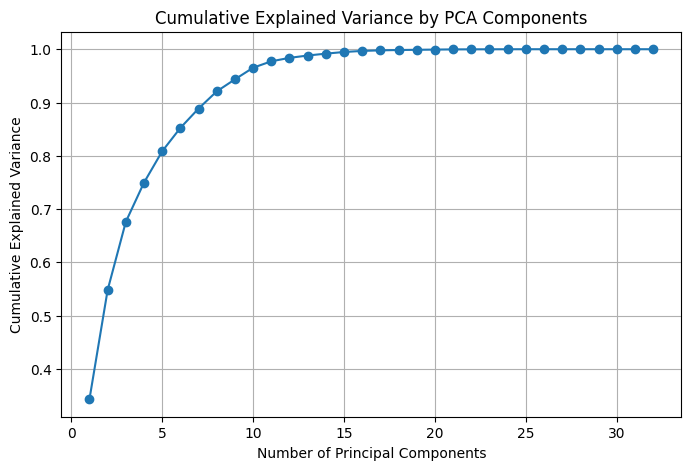


Feature Importance in Principal Components:
PC1:
  RPM[EngineSpeed]: 0.1855
  Load[Pressure]: 0.2935
  BaseFuel[Percentage]: 0.2909
  BaseIgnition[AngleIgnSprt2K]: -0.2095
  TargetAFR[AFR]: -0.1763
  FuelCoolantTempCorrection[Percentage1For1]: 0.0000
  FuelAirTempCorrection[Percentage]: -0.0000
  ThrottlePosition[Percentage]: 0.2984
  AirTemp[Temperature]: 0.0571
  CoolantTemp[Temperature]: 0.0974
  LambdaSensor1[AFR]: 0.1343
  BatteryVoltage[BatteryVoltage]: 0.0186
  EngineRunningTime[Time_s]: 0.0858
  MAPSource[Pressure]: 0.2935
  IgnitionLoad[Pressure]: 0.2935
  AFRDifference[AFR]: -0.1871
  IgnitionTiming[Angle]: -0.2435
  date: 0.0355
  #time_diff: 0.0273
  #time_seq: 0.0857
  #road_seq: -0.1022
  CurrentDutyCycle[Percentage]: 0.2894
  ShiftLight1[Raw]: 0.0266
  IgnitionCoolantTempCorrection[AngleOffset10deg]: -0.2467
  IgnitionAirTempCorrection[Angle]: -0.2038
  TransientThrottleAccelCoolantCorr[Percentage]: -0.0987
  TransientThrottleEnrichSensitivity[Time_us]: -0.2566
  Transi

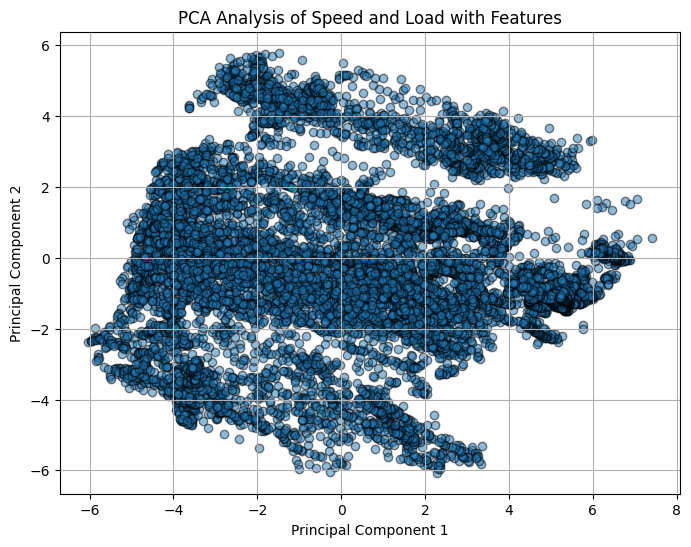

In [ ]:
# cumulative explained variance to decide how many components are significant.
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.show()

print("\nFeature Importance in Principal Components:")
for i in range(3):  # First 3 principal components
    print(f"PC{i+1}:")
    for feature, importance in zip(inputs + features, pca.components_[i]):
        print(f"  {feature}: {importance:.4f}")

# visualizing the first two principal components to detect patterns or clusters.
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.5, edgecolor='k')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Analysis of Speed and Load with Features")
plt.grid(True)
plt.show()

Here we should focus on PC1 since it caputures the direction of most variance and lets see top 15 parameters which vary the most with rest data. We are checking for 15 out of 36 parameters which was intially in our dataset.

In [ ]:
combined_feature_names = inputs + features
pca_loadings = pd.DataFrame(pca.components_.T,
                            index=combined_feature_names,
                            columns=[f'PC{i+1}' for i in range(pca.n_components_)])

pca_loadings['abs_PC1'] = pca_loadings['PC1'].abs()

# sorted the table by the absolute PC1 contribution
sorted_loadings = pca_loadings.sort_values('abs_PC1', ascending=False)

# only the columns of interest
top_factors = sorted_loadings[['PC1']].head(15)

print("Top factors contributing to overall changes (highest |PC1| values):",end='\n\n')
display(top_factors.style.set_caption("Top Factors And Their Loading Scores").set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold')]}]))

Top factors contributing to overall changes (highest |PC1| values):



,PC1
ThrottlePosition[Percentage],0.298433
IgnitionLoad[Pressure],0.293550
Load[Pressure],0.293543
MAPSource[Pressure],0.293456
BaseFuel[Percentage],0.290932
CurrentDutyCycle[Percentage],0.289433
TransientThrottleEnrichSensitivity[Time_us],-0.256648
IgnitionCoolantTempCorrection[AngleOffset10deg],-0.246741
IgnitionTiming[Angle],-0.243453
BaseIgnition[AngleIgnSprt2K],-0.209465


# Factors To Analyze

* So we got like 15 factors that kind of a show a good variation if other data points are changed. Atleast We can infer that much from it. THIS THRESHOLD IS ASSUMED ONE and there isnt any strict boundary to it and we considered it based on the reasoning from analysis of ICE engines as well.


* For ICE analysis and from that point of view we would try inputs to be RPM(Speed) and Load. Further outputs can be Fuel Consumption, Ignition Timing.


* We will also calculate Brake Power by formula and same for fuel consumption.


In [ ]:
# Lets begin by considering the factors of importance
fin_df = filtered_data[['time',
                   'Load[Pressure]',
                   'RPM[EngineSpeed]',
                   'LambdaSensor1[AFR]',
                   'AirTemp[Temperature]',
                   'IgnitionTiming[Angle]',
                   'MAPSource[Pressure]','BaseFuel[Percentage]']].copy()

print("Initial selected data (fin_df):")
print(fin_df.head())

features = ['Load[Pressure]', 'RPM[EngineSpeed]', 'LambdaSensor1[AFR]',
            'AirTemp[Temperature]', 'IgnitionTiming[Angle]', 'MAPSource[Pressure]','BaseFuel[Percentage]']

Initial selected data (fin_df):
                     time  Load[Pressure]  RPM[EngineSpeed]  \
0 2018-07-16 06:18:00.000           422.0            1425.0   
1 2018-07-16 06:18:00.078           422.0            1437.0   
2 2018-07-16 06:18:00.156           422.0            1432.0   
3 2018-07-16 06:18:00.234           423.0            1426.0   
4 2018-07-16 06:18:00.313           423.0            1435.0   

   LambdaSensor1[AFR]  AirTemp[Temperature]  IgnitionTiming[Angle]  \
0               963.0                3155.0                  233.0   
1               962.0                3155.0                  233.0   
2               962.0                3155.0                  233.0   
3               957.0                3155.0                  233.0   
4               956.0                3155.0                  233.0   

   MAPSource[Pressure]  BaseFuel[Percentage]  
0                423.0                 426.0  
1                421.0                 428.0  
2                422.0     

In [ ]:
# constants for engine properties
ENGINE_DISPLACEMENT = 1.5  # liters, assumed engine displacement
GAS_CONSTANT_AIR = 0.287  # kJ/(kg·K)
ARM_LENGTH=0.5 #metres

Vol_eff_Factor = 0.4 # Even 60% vol efficiency is a great factor

fin_df['Torque']=fin_df['Load[Pressure]']*ARM_LENGTH     # have to check normally its by 10 the values obtained now

#Temp correction
fin_df['AirTemp_K'] = fin_df['AirTemp[Temperature]'] + 273.15

fin_df['EngineSpeed_RPS'] = fin_df['RPM[EngineSpeed]'] / 60

fin_df['AirMassFlowRate'] = (
    fin_df['MAPSource[Pressure]'] * ENGINE_DISPLACEMENT * fin_df['EngineSpeed_RPS']
) / (GAS_CONSTANT_AIR * fin_df['AirTemp_K'])  # PV=nRT; n.M(air)=(PV/RT)*M(air) 0.287 kj; m= PV/R(sp)T

fin_df['FuelConsumption'] = (
    Vol_eff_Factor*fin_df['AirMassFlowRate'] / fin_df['LambdaSensor1[AFR]']
)
# adjusting Fuel Consumption using BaseFuel percentage
fin_df['AdjustedFuelConsumption'] = (
    fin_df['FuelConsumption'] * (fin_df['BaseFuel[Percentage]'] / 100)
)

# Brake Power
fin_df['BrakePower(kW)']=2*np.pi*fin_df['EngineSpeed_RPS']*fin_df['Torque']/1000  # kW

print(fin_df[['RPM[EngineSpeed]', 'Load[Pressure]', 'BaseFuel[Percentage]',
                     'AirMassFlowRate', 'FuelConsumption', 'AdjustedFuelConsumption', 'Torque','BrakePower(kW)']].head())

   RPM[EngineSpeed]  Load[Pressure]  BaseFuel[Percentage]  AirMassFlowRate  \
0            1425.0           422.0                 426.0        15.316288   
1            1437.0           422.0                 428.0        15.372240   
2            1432.0           422.0                 427.0        15.355139   
3            1426.0           423.0                 427.0        15.327036   
4            1435.0           423.0                 429.0        15.387308   

   FuelConsumption  AdjustedFuelConsumption  Torque  BrakePower(kW)  
0         0.006362                 0.027102   211.0       31.486612  
1         0.006392                 0.027357   211.0       31.751763  
2         0.006385                 0.027263   211.0       31.641283  
3         0.006406                 0.027355   211.5       31.583373  
4         0.006438                 0.027620   211.5       31.782707  


In [ ]:
fin_df

,time,Load[Pressure],RPM[EngineSpeed],LambdaSensor1[AFR],AirTemp[Temperature],IgnitionTiming[Angle],MAPSource[Pressure],BaseFuel[Percentage],Torque,AirTemp_K,EngineSpeed_RPS,AirMassFlowRate,FuelConsumption,AdjustedFuelConsumption,BrakePower(kW)
0,2018-07-16 06:18:00.000,422.0,1425.0,963.0,3155.0,233.0,423.0,426.0,211.0,3428.15,23.750000,15.316288,0.006362,0.027102,31.486612
1,2018-07-16 06:18:00.078,422.0,1437.0,962.0,3155.0,233.0,421.0,428.0,211.0,3428.15,23.950000,15.372240,0.006392,0.027357,31.751763
2,2018-07-16 06:18:00.156,422.0,1432.0,962.0,3155.0,233.0,422.0,427.0,211.0,3428.15,23.866667,15.355139,0.006385,0.027263,31.641283
3,2018-07-16 06:18:00.234,423.0,1426.0,957.0,3155.0,233.0,423.0,427.0,211.5,3428.15,23.766667,15.327036,0.006406,0.027355,31.583373
4,2018-07-16 06:18:00.313,423.0,1435.0,956.0,3155.0,233.0,422.0,429.0,211.5,3428.15,23.916667,15.387308,0.006438,0.027620,31.782707
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13413,2018-08-23 07:41:59.656,413.0,1075.0,889.0,3028.0,130.0,412.0,352.0,206.5,3301.15,17.916667,11.686879,0.005258,0.018510,23.246477
13414,2018-08-23 07:41:59.719,410.0,1074.0,889.0,3028.0,130.0,411.0,350.0,205.0,3301.15,17.900000,11.647667,0.005241,0.018343,23.056148
13415,2018-08-23 07:41:59.781,410.0,1084.0,891.0,3028.0,130.0,411.0,352.0,205.0,3301.15,18.066667,11.756119,0.005278,0.018578,23.270824
13416,2018-08-23 07:41:59.844,411.0,1058.0,892.0,3028.0,130.0,411.0,348.0,205.5,3301.15,17.633333,11.474145,0.005145,0.017906,22.768064


In [ ]:
# Standardization: Zero mean and unit variance

#standard_scaler = StandardScaler()
#fin_df_standardized = fin_df.copy()
#fin_df_standardized[features] = standard_scaler.fit_transform(fin_df_standardized[features])
#
#print("\nStandardized data (fin_df_standardized):")
#print(fin_df_standardized.head())


Standardized data (fin_df_standardized):
                     time  Load[Pressure]  RPM[EngineSpeed]  \
0 2018-07-16 06:18:00.000       -0.745798         -0.897336   
1 2018-07-16 06:18:00.078       -0.745798         -0.882087   
2 2018-07-16 06:18:00.156       -0.745798         -0.888440   
3 2018-07-16 06:18:00.234       -0.740101         -0.896065   
4 2018-07-16 06:18:00.313       -0.740101         -0.884628   

   LambdaSensor1[AFR]  AirTemp[Temperature]  IgnitionTiming[Angle]  \
0           -0.106948             -0.656258               1.647525   
1           -0.119654             -0.656258               1.647525   
2           -0.119654             -0.656258               1.647525   
3           -0.183183             -0.656258               1.647525   
4           -0.195889             -0.656258               1.647525   

   MAPSource[Pressure]  BaseFuel[Percentage]  Torque  AirTemp_K  \
0            -0.740093             -0.654961   211.0    3428.15   
1            -0.751489  

In [ ]:
# Normalization: Scaling each feature to the [0, 1] range

minmax_scaler = MinMaxScaler()
fin_df_normalized = fin_df.copy()
fin_df_normalized[features] = minmax_scaler.fit_transform(fin_df_normalized[features])

print("\nNormalized data (fin_df_normalized):")
print(fin_df_normalized.head())


Normalized data (fin_df_normalized):
                     time  Load[Pressure]  RPM[EngineSpeed]  \
0 2018-07-16 06:18:00.000        0.330532          0.235476   
1 2018-07-16 06:18:00.078        0.330532          0.238333   
2 2018-07-16 06:18:00.156        0.330532          0.237143   
3 2018-07-16 06:18:00.234        0.331933          0.235714   
4 2018-07-16 06:18:00.313        0.331933          0.237857   

   LambdaSensor1[AFR]  AirTemp[Temperature]  IgnitionTiming[Angle]  \
0            0.747091              0.472727               0.841121   
1            0.746315              0.472727               0.841121   
2            0.746315              0.472727               0.841121   
3            0.742436              0.472727               0.841121   
4            0.741660              0.472727               0.841121   

   MAPSource[Pressure]  BaseFuel[Percentage]  Torque  AirTemp_K  \
0             0.332398              0.409722   211.0    3428.15   
1             0.329593      

In [ ]:
fin_df_normalized

,time,Load[Pressure],RPM[EngineSpeed],LambdaSensor1[AFR],AirTemp[Temperature],IgnitionTiming[Angle],MAPSource[Pressure],BaseFuel[Percentage],Torque,AirTemp_K,EngineSpeed_RPS,AirMassFlowRate,FuelConsumption,AdjustedFuelConsumption,BrakePower(kW)
0,2018-07-16 06:18:00.000,0.330532,0.235476,0.747091,0.472727,0.841121,0.332398,0.409722,211.0,3428.15,23.750000,15.316288,0.006362,0.027102,31.486612
1,2018-07-16 06:18:00.078,0.330532,0.238333,0.746315,0.472727,0.841121,0.329593,0.414352,211.0,3428.15,23.950000,15.372240,0.006392,0.027357,31.751763
2,2018-07-16 06:18:00.156,0.330532,0.237143,0.746315,0.472727,0.841121,0.330996,0.412037,211.0,3428.15,23.866667,15.355139,0.006385,0.027263,31.641283
3,2018-07-16 06:18:00.234,0.331933,0.235714,0.742436,0.472727,0.841121,0.332398,0.412037,211.5,3428.15,23.766667,15.327036,0.006406,0.027355,31.583373
4,2018-07-16 06:18:00.313,0.331933,0.237857,0.741660,0.472727,0.841121,0.330996,0.416667,211.5,3428.15,23.916667,15.387308,0.006438,0.027620,31.782707
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13413,2018-08-23 07:41:59.656,0.317927,0.152143,0.689682,0.087879,0.520249,0.316971,0.238426,206.5,3301.15,17.916667,11.686879,0.005258,0.018510,23.246477
13414,2018-08-23 07:41:59.719,0.313725,0.151905,0.689682,0.087879,0.520249,0.315568,0.233796,205.0,3301.15,17.900000,11.647667,0.005241,0.018343,23.056148
13415,2018-08-23 07:41:59.781,0.313725,0.154286,0.691234,0.087879,0.520249,0.315568,0.238426,205.0,3301.15,18.066667,11.756119,0.005278,0.018578,23.270824
13416,2018-08-23 07:41:59.844,0.315126,0.148095,0.692009,0.087879,0.520249,0.315568,0.229167,205.5,3301.15,17.633333,11.474145,0.005145,0.017906,22.768064


# NBeats Algorithm For TimeSeries Model Training

In [ ]:
# NBeats Architecture

class NBeatsBlock(tf.keras.layers.Layer):
  def __init__(self,
               input_size: int,
               theta_size: int,
               horizon: int,
               n_neurons: int,
               n_layers: int,
               **kwargs):
    super().__init__(**kwargs)
    self.input_size=input_size         # timeseries   1sec - a  2sec -b 3-c      10th sec j....
    self.theta_size=theta_size
    self.horizon=horizon
    self.n_neurons=n_neurons
    self.n_layers=n_layers

    self.hidden=[tf.keras.layers.Dense(n_neurons,activation="relu") for _ in range(n_layers)]
    self.theta_layer=tf.keras.layers.Dense(theta_size,activation="linear",name="theta")

  def call(self,inputs):
      x=inputs
      for layer in self.hidden:
        x=layer(x)
      theta=self.theta_layer(x)
      backcast, forecast = theta[:, :self.input_size], theta[:, -self.horizon:]
      return backcast, forecast

In [ ]:
# lookback window (INPUT_SIZE) and forecast horizon.
WINDOW_SIZE = 5   # no of past time steps
HORIZON = 1        #one time step ahead
INPUT_SIZE = WINDOW_SIZE+2
THETA_SIZE = INPUT_SIZE + HORIZON  # as per Nbeats paper theta is a concatenation of backcast and forecast

In [ ]:
dummy_nbeats_block_layer=NBeatsBlock(input_size=WINDOW_SIZE,
                                       theta_size=INPUT_SIZE+HORIZON, # backcast + forecast
                                       horizon=HORIZON,
                                       n_neurons=128,
                                       n_layers=4)
dummy_inputs=tf.expand_dims(tf.range(WINDOW_SIZE)+1,axis=0)
dummy_inputs

<tf.Tensor: shape=(1, 5), dtype=int32, numpy=array([[1, 2, 3, 4, 5]], dtype=int32)>

In [ ]:
backcast, forecast = dummy_nbeats_block_layer(dummy_inputs)
# These are the activation outputs of the theta layer (they will be random due to no training of the model)
print(f"Backcast: {tf.squeeze(backcast.numpy())}")
print(f"Forecast: {tf.squeeze(forecast.numpy())}")

Backcast: [-0.17484139 -0.16564748  0.42990896  0.02141631  0.238359  ]
Forecast: -0.06336398422718048


In [ ]:
fin_df_normalized_nbeats=fin_df_normalized.copy()
fin_df_normalized_nbeats.set_index('time',inplace=True)
for i in range(WINDOW_SIZE):
   fin_df_normalized_nbeats[f"IgnitionTiming[Angle]+{i+1}"]=fin_df_normalized_nbeats["IgnitionTiming[Angle]"].shift(periods=i+1)
fin_df_normalized_nbeats.dropna().head()

,Load[Pressure],RPM[EngineSpeed],LambdaSensor1[AFR],AirTemp[Temperature],IgnitionTiming[Angle],MAPSource[Pressure],BaseFuel[Percentage],Torque,AirTemp_K,EngineSpeed_RPS,AirMassFlowRate,FuelConsumption,AdjustedFuelConsumption,BrakePower(kW),IgnitionTiming[Angle]+1,IgnitionTiming[Angle]+2,IgnitionTiming[Angle]+3,IgnitionTiming[Angle]+4,IgnitionTiming[Angle]+5
time,,,,,,,,,,,,,,,,,,,
2018-07-16 06:18:00.391,0.331933,0.237619,0.743988,0.472727,0.841121,0.330996,0.416667,211.5,3428.15,23.900000,15.376585,0.006414,0.027514,31.760559,0.841121,0.841121,0.841121,0.841121,0.841121
2018-07-16 06:18:00.469,0.331933,0.242857,0.743212,0.472727,0.844237,0.330996,0.425926,211.5,3428.15,24.266667,15.612488,0.006519,0.028226,32.247820,0.841121,0.841121,0.841121,0.841121,0.841121
2018-07-16 06:18:00.547,0.327731,0.239762,0.741660,0.475758,0.847352,0.328191,0.414352,210.0,3429.15,24.050000,15.395268,0.006442,0.027570,31.733227,0.844237,0.841121,0.841121,0.841121,0.841121
2018-07-16 06:18:00.578,0.326331,0.241190,0.743212,0.472727,0.847352,0.325386,0.414352,209.5,3428.15,24.150000,15.390154,0.006426,0.027503,31.789305,0.847352,0.844237,0.841121,0.841121,0.841121
2018-07-16 06:18:00.625,0.326331,0.244286,0.740109,0.472727,0.847352,0.326788,0.421296,209.5,3428.15,24.366667,15.565379,0.006526,0.028129,32.074509,0.847352,0.847352,0.844237,0.841121,0.841121


In [ ]:
TARGET_COL = 'IgnitionTiming[Angle]'
fin_df_normalized.sort_values("time", inplace=True)

#series = fin_df_normalized[TARGET_COL].values  # univariate output only in Nbeats

In [ ]:
X=fin_df_normalized_nbeats.dropna().drop([TARGET_COL,'LambdaSensor1[AFR]','AirTemp[Temperature]','MAPSource[Pressure]','IgnitionTiming[Angle]','BaseFuel[Percentage]','Torque','AirTemp_K','FuelConsumption','AdjustedFuelConsumption','BrakePower(kW)','EngineSpeed_RPS','AirMassFlowRate'],axis=1)
y=fin_df_normalized_nbeats.dropna()[TARGET_COL]

split_size=int(len(X)*0.8)
X_train,Y_train=X[:split_size],y[:split_size]
X_test,Y_test=X[split_size:],y[split_size:]

In [ ]:
print(len(X_train),len(Y_train),len(X_test),len(Y_test))
X_train[:5],Y_train[:5]

10730 10730 2683 2683


(                         Load[Pressure]  RPM[EngineSpeed]  \
 time                                                        
 2018-07-16 06:18:00.391        0.331933          0.237619   
 2018-07-16 06:18:00.469        0.331933          0.242857   
 2018-07-16 06:18:00.547        0.327731          0.239762   
 2018-07-16 06:18:00.578        0.326331          0.241190   
 2018-07-16 06:18:00.625        0.326331          0.244286   
 
                          IgnitionTiming[Angle]+1  IgnitionTiming[Angle]+2  \
 time                                                                        
 2018-07-16 06:18:00.391                 0.841121                 0.841121   
 2018-07-16 06:18:00.469                 0.841121                 0.841121   
 2018-07-16 06:18:00.547                 0.844237                 0.841121   
 2018-07-16 06:18:00.578                 0.847352                 0.844237   
 2018-07-16 06:18:00.625                 0.847352                 0.847352   
 
                

In [ ]:
# TensorFlow datasets
train_features_dataset=tf.data.Dataset.from_tensor_slices(X_train)
train_labels_dataset=tf.data.Dataset.from_tensor_slices(Y_train)

test_features_dataset=tf.data.Dataset.from_tensor_slices(X_test)
test_labels_dataset=tf.data.Dataset.from_tensor_slices(Y_test)


train_dataset=tf.data.Dataset.zip((train_features_dataset,train_labels_dataset))
test_dataset=tf.data.Dataset.zip((test_features_dataset,test_labels_dataset))


BATCH_SIZE = 1024  # As suggested in the N-BEATS paper
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, Y_test))

train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 10730
Test samples: 2683


In [ ]:
# Hyperparameters for N-BEATS
N_NEURONS = 512
N_LAYERS = 4
N_STACKS = 30
N_EPOCHS = 100

In [ ]:
stack_input = layers.Input(shape=(INPUT_SIZE,), name="stack_input")

# Getting backcast and initial forecast from the first block
initial_block = NBeatsBlock(
    input_size=INPUT_SIZE,
    theta_size=THETA_SIZE,
    horizon=HORIZON,
    n_neurons=N_NEURONS,
    n_layers=N_LAYERS,
    name="NBeatsBlock_initial"
)
backcast, forecast = initial_block(stack_input)
# residual is the diff btw the input series and the block's backcast
residuals = layers.subtract([stack_input, backcast], name="subtract_0")

# initializing the cumulative forecast with the forecast from the first block
cumulative_forecast = forecast

In [ ]:
# stack additional NBeatsBlocks (from 1 to N_STACKS - 1)
for i in range(1, N_STACKS):
    block = NBeatsBlock(
        input_size=INPUT_SIZE,
        theta_size=THETA_SIZE,
        horizon=HORIZON,
        n_neurons=N_NEURONS,
        n_layers=N_LAYERS,
        name=f"NBeatsBlock_{i}"
    )
    backcast_i, forecast_i = block(residuals)
    # update residuals
    residuals = layers.subtract([residuals, backcast_i], name=f"subtract_{i}")
    # accumulating forecasts
    cumulative_forecast = layers.add([cumulative_forecast, forecast_i], name=f"add_{i}")

In [ ]:
# final model
model = Model(inputs=stack_input, outputs=cumulative_forecast, name="NBeats_Model")
model.compile(
    loss="mae",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["mae", "mse"]
)
model.summary()

Model: "NBeats_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ stack_input         │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ NBeatsBlock_initial │ [(None, 7),       │    796,168 │ stack_input[0][0] │
│ (NBeatsBlock)       │ (None, 1)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_0          │ (None, 7)         │          0 │ stack_input[0][0… │
│ (Subtract)          │                   │            │ NBeatsBlock_init… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ NBeatsBlock_1       │ [(None, 7),       │    796,168 │ subtract_0[0][0]  │
│ (NBeatsBlock)       │ (None, 1)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_1          │ (None, 7)         │          0 │ subtract_0[0][0], │
│ (Subtract)          │                   │            │ NBeatsBlock_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ NBeatsBlock_2       │ [(None, 7),       │    796,168 │ subtract_1[0][0]  │
│ (NBeatsBlock)       │ (None, 1)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_2          │ (None, 7)         │          0 │ subtract_1[0][0], │
│ (Subtract)          │                   │            │ NBeatsBlock_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ NBeatsBlock_3       │ [(None, 7),       │    796,168 │ subtract_2[0][0]  │
│ (NBeatsBlock)       │ (None, 1)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_3          │ (None, 7)         │          0 │ subtract_2[0][0], │
│ (Subtract)          │                   │            │ NBeatsBlock_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ NBeatsBlock_4       │ [(None, 7),       │    796,168 │ subtract_3[0][0]  │
│ (NBeatsBlock)       │ (None, 1)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_4          │ (None, 7)         │          0 │ subtract_3[0][0], │
│ (Subtract)          │                   │            │ NBeatsBlock_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ NBeatsBlock_5       │ [(None, 7),       │    796,168 │ subtract_4[0][0]  │
│ (NBeatsBlock)       │ (None, 1)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_5          │ (None, 7)         │          0 │ subtract_4[0][0], │
│ (Subtract)          │                   │            │ NBeatsBlock_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ NBeatsBlock_6       │ [(None, 7),       │    796,168 │ subtract_5[0][0]  │
│ (NBeatsBlock)       │ (None, 1)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_6          │ (None, 7)         │          0 │ subtract_5[0][0], │
│ (Subtract)          │                   │            │ NBeatsBlock_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ NBeatsBlock_7       │ [(None, 7),       │    796,168 │ subtract_6[0][0]  │
│ (NBeatsBlock)       │ (None, 1)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_7          │ (None, 7)         │          0 │ subtract_6[0][0]

 Total params: 23,885,040 (91.11 MB)

 Trainable params: 23,885,040 (91.11 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
plot_model(model, show_shapes=True)

In [ ]:
#EarlyStopping and ReduceLROnPlateau callbacks applied and model fitting
with parallel_backend('threading',n_jobs=-1): # multiprocessing
   model.fit(train_dataset,
               epochs=N_EPOCHS,
               validation_data=test_dataset,
               verbose=1,
               callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=200, restore_best_weights=True),
                         tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=100, verbose=1)])

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class parallel_backend is deprecated; deprecated in 1.5 to be removed in 1.7. Use joblib.{} instead.
  warnings.warn(msg, category=FutureWarning)


11/11 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - loss: 3.6889 - mae: 3.6889 - mse: 48.2804 - val_loss: 0.0726 - val_mae: 0.0726 - val_mse: 0.0073 - learning_rate: 0.0010
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - loss: 0.0706 - mae: 0.0706 - mse: 0.0074 - val_loss: 0.1840 - val_mae: 0.1840 - val_mse: 0.0353 - learning_rate: 0.0010
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - loss: 0.1512 - mae: 0.1512 - mse: 0.0284 - val_loss: 0.0807 - val_mae: 0.0807 - val_mse: 0.0081 - learning_rate: 0.0010
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - loss: 0.0487 - mae: 0.0487 - mse: 0.0043 - val_loss: 0.0294 - val_mae: 0.0294 - val_mse: 0.0015 - learning_rate: 0.0010
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.0425 - mae: 0.0425 - mse: 0.0031 - val_loss: 0.0742 - val_mae: 0.0742 - val_mse: 0.0060 - learning_rate: 0.0010
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.0848 - mae: 0.0848 - mse: 0.0094 - val_loss: 0.0418 - val_mae: 0.0418 - val

In [ ]:
model.evaluate(test_dataset)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0111 - mae: 0.0111 - mse: 2.8824e-04


[0.010532883927226067, 0.010532883927226067, 0.0002656803699210286]

In [ ]:
def make_preds(model,input_data):
  forecast=model.predict(input_data)
  return tf.squeeze(forecast)

def evaluate_preds(y_true, y_pred):
    """evaluates the predictions against the true values using various metrics.

    args:
        y_true: The true values.
        y_pred: The predicted values.

    returns:
        a dictionary containing the calculated metrics.
    """
    y_true = y_true.values if isinstance(y_true, pd.Series) else y_true
    y_pred = y_pred.values if isinstance(y_pred, pd.Series) else y_pred

    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(y_pred, dtype=tf.float32)

    mae = tf.keras.metrics.MeanAbsoluteError()
    mse = tf.keras.metrics.MeanSquaredError()
    mape = tf.keras.metrics.MeanAbsolutePercentageError()

    mae.update_state(y_true, y_pred)
    mse.update_state(y_true, y_pred)
    mape.update_state(y_true, y_pred)
    rmse = tf.sqrt(mse.result())
    #mase = tf.mean_absolute_scaled_error(y_true, y_pred) # Ensure mean_absolute_scaled_error function is correctly imported or defined

    return {
        "mae": mae.result().numpy(),
        "mse": mse.result().numpy(),
        "rmse": rmse.numpy(),
        "mape": mape.result().numpy(),
        #"mase": mase.numpy()
    }

In [ ]:
model_preds=make_preds(model=model,
                         input_data=test_dataset)
model_preds[:5]

3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step


<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([0.5545075 , 0.55273014, 0.54430956, 0.5348125 , 0.53173053],
      dtype=float32)>

In [ ]:
model_results=evaluate_preds(y_true=Y_test,
                               y_pred=model_preds)

model_results

{'mae': np.float32(0.010532883),
 'mse': np.float32(0.00026568037),
 'rmse': np.float32(0.016299704),
 'mape': np.float32(2.9288576)}

In [ ]:
def objective(trial):

    time.sleep(0.1)
    # hyperparameters to optimize.
    n_neurons = trial.suggest_int("n_neurons", 256, 1024, step=128)
    n_layers = trial.suggest_int("n_layers", 2, 6)
    n_stacks = trial.suggest_int("n_stacks", 1, 30)
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)

    stack_input = layers.Input(shape=(INPUT_SIZE,), name="stack_input")

    initial_block = NBeatsBlock(
        input_size=INPUT_SIZE,
        theta_size=THETA_SIZE,
        horizon=HORIZON,
        n_neurons=n_neurons,
        n_layers=n_layers,
        name="NBeatsBlock_0"
    )
    backcast, forecast = initial_block(stack_input)

    residuals = layers.subtract([stack_input, backcast], name="subtract_0")
    cumulative_forecast = forecast

    for i in range(1, n_stacks):
        block = NBeatsBlock(
            input_size=INPUT_SIZE,
            theta_size=THETA_SIZE,
            horizon=HORIZON,
            n_neurons=n_neurons,
            n_layers=n_layers,
            name=f"NBeatsBlock_{i}"
        )
        backcast_i, forecast_i = block(residuals)
        residuals = layers.subtract([residuals, backcast_i], name=f"subtract_{i}")
        cumulative_forecast = layers.add([cumulative_forecast, forecast_i], name=f"add_{i}")

    model = Model(inputs=stack_input, outputs=cumulative_forecast, name="NBeats_Model")
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss="mae")
    early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True)

    with parallel_backend('threading',n_jobs=-1):
       model.fit(train_dataset,
                 epochs=500,
                 validation_data=test_dataset,
                 callbacks=[early_stop],
                 verbose=0)

    val_loss = model.evaluate(test_dataset, verbose=0)
    return val_loss

In [ ]:
class SpinnerCallback(object):
    def __init__(self, spinner):
        self.spinner = spinner

    def __call__(self, study, trial):
        self.spinner.text = (f"Trial {trial.number} completed | "
                               f"Current best loss: {study.best_value:.4f}")

study=optuna.create_study(direction="minimize")

with yaspin(text="Optimizing hyperparameters...", color="cyan") as spinner:
    study.optimize(objective, n_trials=50, callbacks=[SpinnerCallback(spinner)])
    spinner.ok("✅ ")

print("\nBest hyperparameters found:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

[I 2025-04-23 18:18:11,168] A new study created in memory with name: no-name-16bf8b71-d661-4144-bd98-a0bf11df8541


⠹ Optimizing hyperparameters...

/usr/local/lib/python3.11/dist-packages/yaspin/core.py:128: UserWarning: color, on_color and attrs are not supported when running in jupyter
  self._color = self._set_color(color) if color else color
<ipython-input-51-de9a2350687a>:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)


⠏ Optimizing hyperparameters...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class parallel_backend is deprecated; deprecated in 1.5 to be removed in 1.7. Use joblib.{} instead.
  warnings.warn(msg, category=FutureWarning)


⠴ Optimizing hyperparameters...

[I 2025-04-23 18:20:49,854] Trial 0 finished with value: 0.008547047153115273 and parameters: {'n_neurons': 640, 'n_layers': 2, 'n_stacks': 21, 'learning_rate': 0.0036071055273743592}. Best is trial 0 with value: 0.008547047153115273.


⠏ Trial 0 completed | Current best loss: 0.0085

[I 2025-04-23 18:21:13,160] Trial 1 finished with value: 0.008155906572937965 and parameters: {'n_neurons': 640, 'n_layers': 3, 'n_stacks': 2, 'learning_rate': 0.00035287543790824113}. Best is trial 1 with value: 0.008155906572937965.


⠏ Trial 1 completed | Current best loss: 0.0082

[I 2025-04-23 18:24:54,481] Trial 2 finished with value: 0.007640623953193426 and parameters: {'n_neurons': 1024, 'n_layers': 5, 'n_stacks': 4, 'learning_rate': 0.0008826078690055781}. Best is trial 2 with value: 0.007640623953193426.


⠏ Trial 2 completed | Current best loss: 0.0076

[I 2025-04-23 18:29:38,321] Trial 3 finished with value: 0.009823154658079147 and parameters: {'n_neurons': 1024, 'n_layers': 3, 'n_stacks': 14, 'learning_rate': 0.0027095285772720393}. Best is trial 2 with value: 0.007640623953193426.


⠇ Trial 3 completed | Current best loss: 0.0076

[I 2025-04-23 18:31:40,519] Trial 4 finished with value: 0.011071153916418552 and parameters: {'n_neurons': 256, 'n_layers': 6, 'n_stacks': 17, 'learning_rate': 0.005245963489163303}. Best is trial 2 with value: 0.007640623953193426.


⠙ Trial 4 completed | Current best loss: 0.0076

[I 2025-04-23 18:33:12,552] Trial 5 finished with value: 0.00856912974268198 and parameters: {'n_neurons': 256, 'n_layers': 3, 'n_stacks': 19, 'learning_rate': 0.0001239474560161751}. Best is trial 2 with value: 0.007640623953193426.


⠼ Trial 5 completed | Current best loss: 0.0076

[I 2025-04-23 18:33:35,647] Trial 6 finished with value: 0.010212104767560959 and parameters: {'n_neurons': 640, 'n_layers': 4, 'n_stacks': 1, 'learning_rate': 0.00141062764164237}. Best is trial 2 with value: 0.007640623953193426.


⠸ Trial 6 completed | Current best loss: 0.0076

[W 2025-04-23 18:38:07,769] Trial 7 failed with parameters: {'n_neurons': 1024, 'n_layers': 2, 'n_stacks': 25, 'learning_rate': 0.00042809199404071353} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "<ipython-input-51-de9a2350687a>", line 44, in objective
    model.fit(train_dataset,
  File "/usr/local/lib/python3.11/dist-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py", line 371, in fit
    logs = self.train_function(iterator)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py", line 220, in function
    if not opt_outputs.h

KeyboardInterrupt: 

In [ ]:
a=max(fin_df['RPM[EngineSpeed]'])-min(fin_df['RPM[EngineSpeed]'])
b=max(fin_df['Load[Pressure]'])-min(fin_df['Load[Pressure]'])
c=max(fin_df['IgnitionTiming[Angle]'])-min(fin_df['IgnitionTiming[Angle]'])
d=max(fin_df['AdjustedFuelConsumption'])-min(fin_df['AdjustedFuelConsumption'])
print(a,b,c,d)

4200.0 714.0 321.0 inf


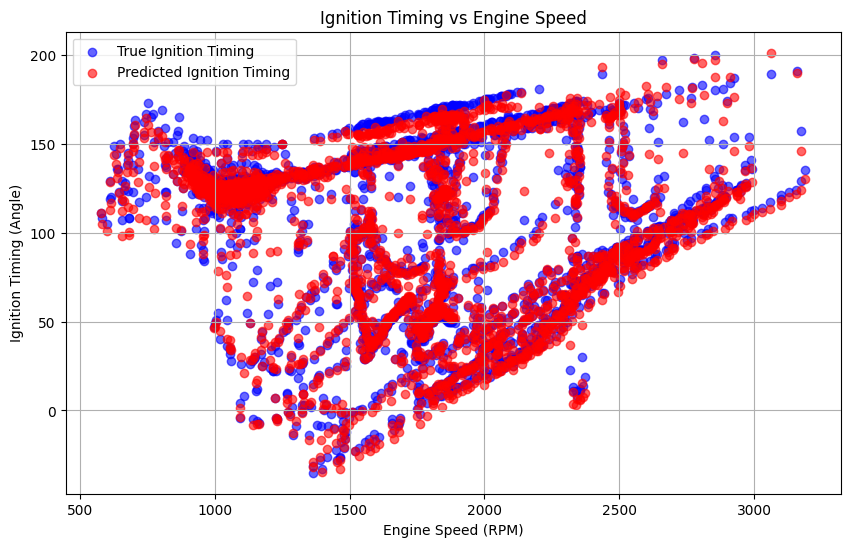

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# it's to be a 1D array:
y_pred = np.squeeze(model_preds)  # shape becomes (num_samples, )

RPM_test = X_test.iloc[:, 1].values
Load_test = X_test.iloc[:, 0].values

RPM_test_de=RPM_test*a+min(fin_df['RPM[EngineSpeed]'])
Load_test_de=Load_test*b+min(fin_df['Load[Pressure]'])
y_pred_de=y_pred*c+min(fin_df['IgnitionTiming[Angle]'])
Y_test_de=Y_test*c+min(fin_df['IgnitionTiming[Angle]'])

# Graph 1: Ignition Timing vs Engine Speed
plt.figure(figsize=(10, 6))
plt.scatter(RPM_test_de, Y_test_de, color='blue', label='True Ignition Timing', alpha=0.6)
plt.scatter(RPM_test_de, y_pred_de, color='red', label='Predicted Ignition Timing', alpha=0.6)
plt.xlabel('Engine Speed (RPM)')
plt.ylabel('Ignition Timing (Angle)')
plt.title('Ignition Timing vs Engine Speed')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(Load_test)
print(RPM_test)
print(y_pred)

[0.42997199 0.43977591 0.45238095 ... 0.31372549 0.31512605 0.31932773]
[0.33309524 0.32261905 0.31785714 ... 0.15428571 0.14809524 0.14785714]
[0.5545075  0.55273014 0.54430956 ... 0.51232266 0.5124393  0.512301  ]


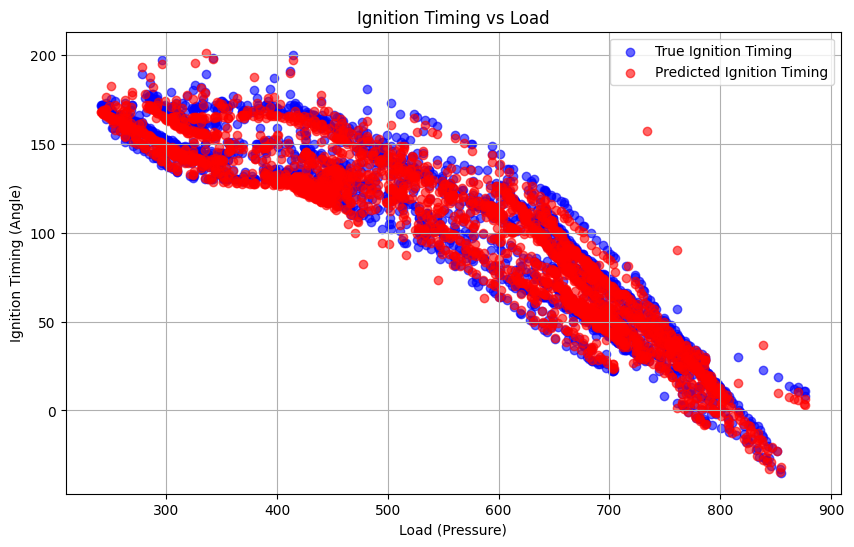

In [ ]:
# Graph 2: Ignition Timing vs Load

plt.figure(figsize=(10, 6))
plt.scatter(Load_test_de, Y_test_de, color='blue', label='True Ignition Timing', alpha=0.6)
plt.scatter(Load_test_de, y_pred_de, color='red', label='Predicted Ignition Timing', alpha=0.6)
plt.xlabel('Load (Pressure)')
plt.ylabel('Ignition Timing (Angle)')
plt.title('Ignition Timing vs Load')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
fin_df_normalized
#print(min(fin_df_normalized['LambdaSensor1[AFR]']))

,time,Load[Pressure],RPM[EngineSpeed],LambdaSensor1[AFR],AirTemp[Temperature],IgnitionTiming[Angle],MAPSource[Pressure],BaseFuel[Percentage],Torque,AirTemp_K,EngineSpeed_RPS,AirMassFlowRate,FuelConsumption,AdjustedFuelConsumption,BrakePower(kW)
0,2018-07-16 06:18:00.000,0.330532,0.235476,0.747091,0.472727,0.841121,0.332398,0.409722,211.0,3428.15,23.750000,15.316288,0.006362,0.027102,31.486612
1,2018-07-16 06:18:00.078,0.330532,0.238333,0.746315,0.472727,0.841121,0.329593,0.414352,211.0,3428.15,23.950000,15.372240,0.006392,0.027357,31.751763
2,2018-07-16 06:18:00.156,0.330532,0.237143,0.746315,0.472727,0.841121,0.330996,0.412037,211.0,3428.15,23.866667,15.355139,0.006385,0.027263,31.641283
3,2018-07-16 06:18:00.234,0.331933,0.235714,0.742436,0.472727,0.841121,0.332398,0.412037,211.5,3428.15,23.766667,15.327036,0.006406,0.027355,31.583373
4,2018-07-16 06:18:00.313,0.331933,0.237857,0.741660,0.472727,0.841121,0.330996,0.416667,211.5,3428.15,23.916667,15.387308,0.006438,0.027620,31.782707
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13413,2018-08-23 07:41:59.656,0.317927,0.152143,0.689682,0.087879,0.520249,0.316971,0.238426,206.5,3301.15,17.916667,11.686879,0.005258,0.018510,23.246477
13414,2018-08-23 07:41:59.719,0.313725,0.151905,0.689682,0.087879,0.520249,0.315568,0.233796,205.0,3301.15,17.900000,11.647667,0.005241,0.018343,23.056148
13415,2018-08-23 07:41:59.781,0.313725,0.154286,0.691234,0.087879,0.520249,0.315568,0.238426,205.0,3301.15,18.066667,11.756119,0.005278,0.018578,23.270824
13416,2018-08-23 07:41:59.844,0.315126,0.148095,0.692009,0.087879,0.520249,0.315568,0.229167,205.5,3301.15,17.633333,11.474145,0.005145,0.017906,22.768064


In [ ]:
fin_df

,time,Load[Pressure],RPM[EngineSpeed],LambdaSensor1[AFR],AirTemp[Temperature],IgnitionTiming[Angle],MAPSource[Pressure],BaseFuel[Percentage],Torque,AirTemp_K,EngineSpeed_RPS,AirMassFlowRate,FuelConsumption,AdjustedFuelConsumption,BrakePower(kW)
0,2018-07-16 06:18:00.000,422.0,1425.0,963.0,3155.0,233.0,423.0,426.0,211.0,3428.15,23.750000,15.316288,0.006362,0.027102,31.486612
1,2018-07-16 06:18:00.078,422.0,1437.0,962.0,3155.0,233.0,421.0,428.0,211.0,3428.15,23.950000,15.372240,0.006392,0.027357,31.751763
2,2018-07-16 06:18:00.156,422.0,1432.0,962.0,3155.0,233.0,422.0,427.0,211.0,3428.15,23.866667,15.355139,0.006385,0.027263,31.641283
3,2018-07-16 06:18:00.234,423.0,1426.0,957.0,3155.0,233.0,423.0,427.0,211.5,3428.15,23.766667,15.327036,0.006406,0.027355,31.583373
4,2018-07-16 06:18:00.313,423.0,1435.0,956.0,3155.0,233.0,422.0,429.0,211.5,3428.15,23.916667,15.387308,0.006438,0.027620,31.782707
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13413,2018-08-23 07:41:59.656,413.0,1075.0,889.0,3028.0,130.0,412.0,352.0,206.5,3301.15,17.916667,11.686879,0.005258,0.018510,23.246477
13414,2018-08-23 07:41:59.719,410.0,1074.0,889.0,3028.0,130.0,411.0,350.0,205.0,3301.15,17.900000,11.647667,0.005241,0.018343,23.056148
13415,2018-08-23 07:41:59.781,410.0,1084.0,891.0,3028.0,130.0,411.0,352.0,205.0,3301.15,18.066667,11.756119,0.005278,0.018578,23.270824
13416,2018-08-23 07:41:59.844,411.0,1058.0,892.0,3028.0,130.0,411.0,348.0,205.5,3301.15,17.633333,11.474145,0.005145,0.017906,22.768064


In [ ]:
dffin=fin_df_normalized

In [ ]:
dffin['RPM[EngineSpeed]_Final']=dffin['RPM[EngineSpeed]']*a+min(fin_df['RPM[EngineSpeed]'])
dffin['Load[Pressure]_Final']=dffin['Load[Pressure]']*b+min(fin_df['Load[Pressure]'])
dffin['IgnitionTiming[Angle]_Final']=dffin['IgnitionTiming[Angle]']*c+min(fin_df['IgnitionTiming[Angle]'])

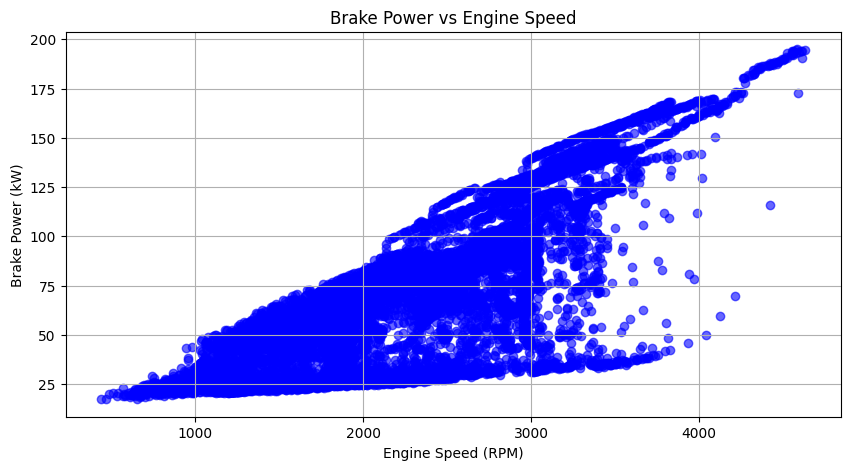

In [ ]:
#Brake Power vs Engine Speed
plt.figure(figsize=(10,5))
plt.scatter(dffin['RPM[EngineSpeed]_Final'],dffin['BrakePower(kW)'],alpha=0.6,color='blue')
plt.xlabel('Engine Speed (RPM)')
plt.ylabel('Brake Power (kW)')
plt.title('Brake Power vs Engine Speed')
plt.grid(True)
plt.show()

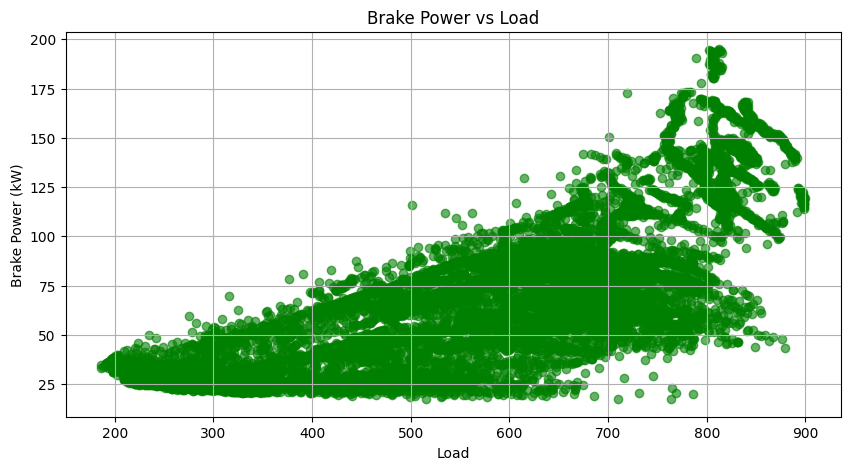

In [ ]:
#Brake Power vs Load
plt.figure(figsize=(10,5))
plt.scatter(dffin['Load[Pressure]_Final'],dffin['BrakePower(kW)'],alpha=0.6,color='green')
plt.xlabel('Load')
plt.ylabel('Brake Power (kW)')
plt.title('Brake Power vs Load')
plt.grid(True)
plt.show()

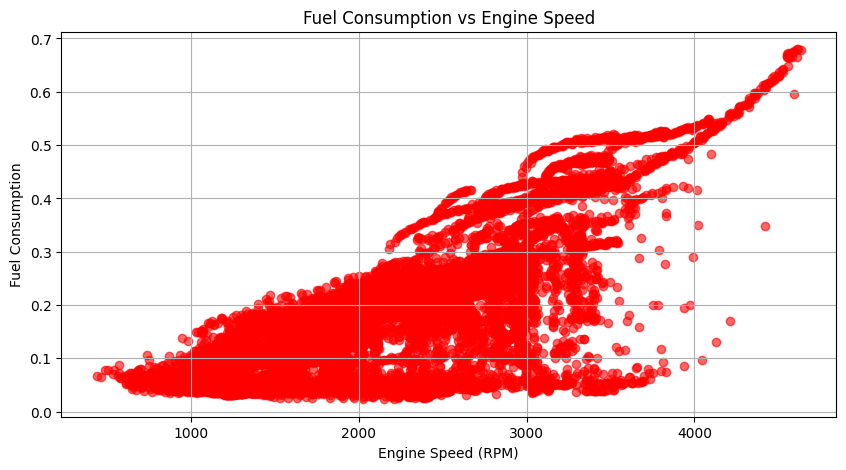

In [ ]:
#Fuel Consumption vs Engine Speed
plt.figure(figsize=(10,5))
plt.scatter(dffin['RPM[EngineSpeed]_Final'],dffin['AdjustedFuelConsumption'],alpha=0.6,color='red')
plt.xlabel('Engine Speed (RPM)')
plt.ylabel('Fuel Consumption')
plt.title('Fuel Consumption vs Engine Speed')
plt.grid(True)
plt.show()

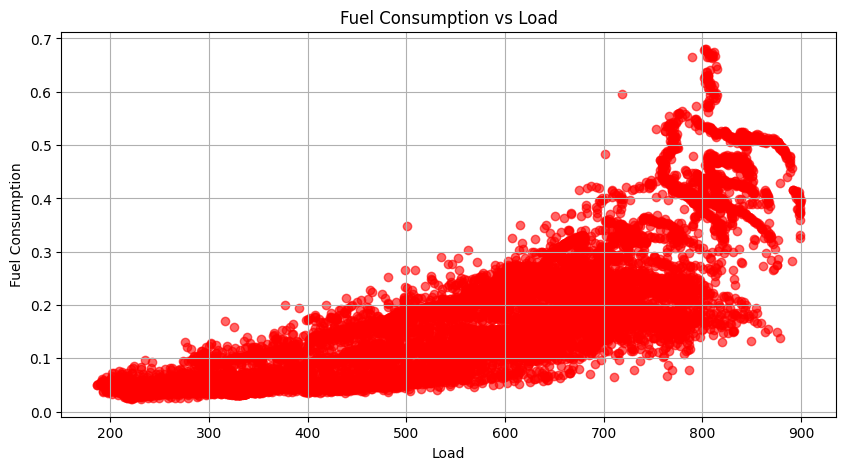

In [ ]:
#Fuel Consumption vs Load
plt.figure(figsize=(10,5))
plt.scatter(dffin['Load[Pressure]_Final'],dffin['AdjustedFuelConsumption'],alpha=0.6,color='red')
plt.xlabel('Load')
plt.ylabel('Fuel Consumption')
plt.title('Fuel Consumption vs Load')
plt.grid(True)
plt.show()